# Document Automation & Image Extraction Pipeline
This notebook automates reading student data, cropping specific regions (Comments, Signature, Date) from raw scans, and injecting both text and images into a Word template.

In [1]:
# 1. Setup & Initialization
import pandas as pd
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt
from docxtpl import DocxTemplate, InlineImage
from docx.shared import Mm
import logging
from datetime import datetime

# Define global variables for file paths based on workspace structure
CSV_PATH = "data/tables/WPL_02_Final_Dataset.csv"
SCANS_DIR = "data/raw_scans/"
# Ensure this matches exactly the filename in your templates folder
TEMPLATE_PATH = "data/templates/injection/WPL 02_Rubric for GA12_Workplace Practices_Adjusted.docx"
FULL_PAGE_TEMPLATE_PATH = "data/templates/extraction/full_page_template.png"

OUTPUT_DOCS_DIR = "data/output/docs/"
OUTPUT_SIGNATURES_DIR = "data/output/signatures/"
LOG_DIR = "logs/process_logs/"

# Create necessary directories
for d in [OUTPUT_DOCS_DIR, OUTPUT_SIGNATURES_DIR, LOG_DIR]:
    os.makedirs(d, exist_ok=True)

# Set up logging
log_file = os.path.join(LOG_DIR, f"process_{datetime.now().strftime('%Y%m%d_%H%M%S')}.log")
logging.basicConfig(filename=log_file, level=logging.INFO, 
                    format='%(asctime)s - %(levelname)s - %(message)s')
print("Setup complete. Directories created and logging initialized.")

Setup complete. Directories created and logging initialized.


In [2]:
# 2. Helper Functions: Image Alignment & Cropping

# 🔧 ROI Coordinate Mapping (Relative to the FULL image)
DYNAMIC_ANCHOR_MAP = {
    'comment': {
        'anchor_path': 'data/templates/extraction/comment_anchor.png',
        'offset_x': 0,
        'offset_y': 0,
        'crop_w': 1480,
        'crop_h': 120,
        'threshold': 0.65
    },
    'signature': {
        'anchor_path': 'data/templates/extraction/signature_anchor.png',
        'offset_x': 256,
        'offset_y': 20,
        'crop_w': 885,
        'crop_h': 71,
        'threshold': 0.55
    },
    'date': {
        'anchor_path': 'data/templates/extraction/date_anchor.png',
        'offset_x': 0,
        'offset_y': 0,
        'crop_w': 340,
        'crop_h': 73,
        'threshold': 0.65
    }
}

def is_homography_valid(H):
    """
    Validates whether the homography matrix is degenerate or extreme.
    Checks the determinant of the affine transformation part and perspective distort coefficients.
    """
    if H is None:
        return False
    det = H[0, 0] * H[1, 1] - H[0, 1] * H[1, 0]
    # Scale scale threshold (~0.3x to ~3.1x)
    if det <= 0.1 or det >= 10.0:
        return False
    # Check perspective distortion components (should be close to zero for flat document scans)
    if abs(H[2, 0]) > 0.002 or abs(H[2, 1]) > 0.002:
        return False
    return True

def align_images(img, template_img, max_features=5000):
    """
    Uses SIFT feature detection and FLANN matching to compute a homography matrix 
    and warp the raw scan (img) to align perfectly with the dimensions of the template_img.
    If the homography fails validation, falls back to aspect-ratio resizing.
    """
    logging.info("[align_images] INFO - Starting feature detection and matching")
    print("[align_images] INFO - Starting feature detection and matching")
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    template_gray = cv2.cvtColor(template_img, cv2.COLOR_BGR2GRAY)
    
    # Use SIFT instead of ORB for better accuracy across scale/rotation differences
    sift = cv2.SIFT_create(max_features)
    kpsA, descsA = sift.detectAndCompute(img_gray, None)
    kpsB, descsB = sift.detectAndCompute(template_gray, None)
    
    if descsA is None or descsB is None:
        logging.warning("[align_images] WARNING - No SIFT descriptors, falling back to aspect-ratio resizing")
        print("[align_images] WARNING - No SIFT descriptors, falling back to aspect-ratio resizing")
        return cv2.resize(img, (template_img.shape[1], template_img.shape[0]))

    # Use FLANN matcher
    FLANN_INDEX_KDTREE = 1
    index_params = dict(algorithm=FLANN_INDEX_KDTREE, trees=5)
    search_params = dict(checks=50)
    flann = cv2.FlannBasedMatcher(index_params, search_params)
    matches = flann.knnMatch(descsA, descsB, k=2)
    
    good_matches = []
    for m_n in matches:
        if len(m_n) != 2:
            continue
        m, n = m_n
        if m.distance < 0.7 * n.distance:
            good_matches.append(m)
            
    MIN_MATCH_COUNT = 10
    if len(good_matches) < MIN_MATCH_COUNT:
        logging.warning(f"[align_images] WARNING - Insufficient good matches ({len(good_matches)}/{MIN_MATCH_COUNT}), falling back to aspect-ratio resizing")
        print(f"[align_images] WARNING - Insufficient good matches ({len(good_matches)}/{MIN_MATCH_COUNT}), falling back to aspect-ratio resizing")
        return cv2.resize(img, (template_img.shape[1], template_img.shape[0]))
        
    ptsA = np.zeros((len(good_matches), 2), dtype="float32")
    ptsB = np.zeros((len(good_matches), 2), dtype="float32")
    for (i, m) in enumerate(good_matches):
        ptsA[i] = kpsA[m.queryIdx].pt
        ptsB[i] = kpsB[m.trainIdx].pt
        
    # Compute homography using RANSAC
    (H, mask) = cv2.findHomography(ptsA, ptsB, cv2.RANSAC, 5.0)
    
    if is_homography_valid(H):
        logging.info("[align_images] SUCCESS - Homography matrix is valid. Warping perspective...")
        print("[align_images] SUCCESS - Homography matrix is valid. Warping perspective...")
        (h, w) = template_img.shape[:2]
        aligned_img = cv2.warpPerspective(img, H, (w, h))
        return aligned_img
    else:
        logging.warning("[align_images] WARNING - Homography matrix is degenerate, falling back to aspect-ratio resizing")
        print("[align_images] WARNING - Homography matrix is degenerate, falling back to aspect-ratio resizing")
        return cv2.resize(img, (template_img.shape[1], template_img.shape[0]))

def crop_dynamic_region(aligned_img, anchor_img_path, offset_x, offset_y, crop_w, crop_h, threshold=0.65):
    """
    Finds the anchor image inside aligned_img using template matching,
    and crops a region relative to the anchor's top-left location.
    """
    logging.info(f"[crop_dynamic_region] INFO - Loading anchor template image: {anchor_img_path}")
    print(f"[crop_dynamic_region] INFO - Loading anchor template image: {anchor_img_path}")
    gray_img = cv2.cvtColor(aligned_img, cv2.COLOR_BGR2GRAY)
    
    if not os.path.exists(anchor_img_path):
        logging.error(f"[crop_dynamic_region] ERROR - Anchor template image not found: {anchor_img_path}")
        print(f"[crop_dynamic_region] ERROR - Anchor template image not found: {anchor_img_path}")
        return None
        
    anchor_img = cv2.imread(anchor_img_path, cv2.IMREAD_GRAYSCALE)
    if anchor_img is None:
        logging.error(f"[crop_dynamic_region] ERROR - Failed to read anchor template image: {anchor_img_path}")
        print(f"[crop_dynamic_region] ERROR - Failed to read anchor template image: {anchor_img_path}")
        return None
        
    logging.info(f"[crop_dynamic_region] INFO - Performing template matching using cv2.TM_CCOEFF_NORMED")
    print(f"[crop_dynamic_region] INFO - Performing template matching using cv2.TM_CCOEFF_NORMED")
    res = cv2.matchTemplate(gray_img, anchor_img, cv2.TM_CCOEFF_NORMED)
    min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(res)
    
    if max_val < threshold:
        logging.warning(f"[crop_dynamic_region] WARNING - Match confidence {max_val:.2f} is below threshold {threshold} for {anchor_img_path}")
        print(f"[crop_dynamic_region] WARNING - Match confidence {max_val:.2f} is below threshold {threshold} for {anchor_img_path}")
        return None
        
    logging.info(f"[crop_dynamic_region] SUCCESS - Match confidence: {max_val:.2f} (Threshold: {threshold}) at {max_loc}")
    print(f"[crop_dynamic_region] SUCCESS - Match confidence: {max_val:.2f} (Threshold: {threshold}) at {max_loc}")
    
    anchor_x, anchor_y = max_loc
    start_x = anchor_x + offset_x
    start_y = anchor_y + offset_y
    end_x = start_x + crop_w
    end_y = start_y + crop_h
    
    img_h, img_w = aligned_img.shape[:2]
    crop_x_start = max(0, min(img_w, start_x))
    crop_x_end = max(0, min(img_w, end_x))
    crop_y_start = max(0, min(img_h, start_y))
    crop_y_end = max(0, min(img_h, end_y))
    
    if (crop_x_end - crop_x_start) <= 0 or (crop_y_end - crop_y_start) <= 0:
        logging.error(f"[crop_dynamic_region] ERROR - Invalid crop dimensions: {crop_x_start}:{crop_x_end}, {crop_y_start}:{crop_y_end}")
        print(f"[crop_dynamic_region] ERROR - Invalid crop dimensions: {crop_x_start}:{crop_x_end}, {crop_y_start}:{crop_y_end}")
        return None
        
    logging.info(f"[crop_dynamic_region] SUCCESS - Cropping region ({crop_x_start}:{crop_x_end}, {crop_y_start}:{crop_y_end})")
    print(f"[crop_dynamic_region] SUCCESS - Cropping region ({crop_x_start}:{crop_x_end}, {crop_y_start}:{crop_y_end})")
    return aligned_img[crop_y_start:crop_y_end, crop_x_start:crop_x_end]

def extract_image_blocks(image_path, page_no):
    """
    Loads an image, aligns it via Homography to the base template,
    crops specific regions using precise ROI coordinates defined in DYNAMIC_ANCHOR_MAP,
    and saves them using the page_no.
    """
    logging.info(f"[extract_image_blocks] INFO - Processing page: {page_no} from {image_path}")
    print(f"[extract_image_blocks] INFO - Processing page: {page_no} from {image_path}")
    img = cv2.imread(str(image_path))
    template_img = cv2.imread(FULL_PAGE_TEMPLATE_PATH)
    
    if img is None:
        logging.error(f"[extract_image_blocks] ERROR - Failed to load image: {image_path}")
        print(f"[extract_image_blocks] ERROR - Failed to load image: {image_path}")
        return None
        
    if template_img is None:
        logging.error(f"[extract_image_blocks] ERROR - Failed to load template image: {FULL_PAGE_TEMPLATE_PATH}")
        print(f"[extract_image_blocks] ERROR - Failed to load template image: {FULL_PAGE_TEMPLATE_PATH}")
        return None

    # Skip homography alignment if the image has EXACTLY the same dimensions as the template
    if img.shape == template_img.shape:
        logging.info("[extract_image_blocks] INFO - Image dimensions already match full page. Bypassing homography...")
        print("[extract_image_blocks] INFO - Image dimensions already match full page. Bypassing homography...")
        aligned = img
    else:
        # Align via homography to match the full page
        logging.info(f"[extract_image_blocks] INFO - Aligning {image_path} with full page homography...")
        print(f"[extract_image_blocks] INFO - Aligning {image_path} with full page homography...")
        aligned = align_images(img, template_img)

    # Dictionary to store successfully saved crop paths
    saved_crops = {}

    # Crop exactly using the dynamic matching configuration from DYNAMIC_ANCHOR_MAP
    for block_name, config in DYNAMIC_ANCHOR_MAP.items():
        # Only process 'signature' as requested, omitting comments and date crops from scans
        if block_name != 'signature':
            continue
            
        crop_img = crop_dynamic_region(
            aligned,
            config['anchor_path'],
            config['offset_x'],
            config['offset_y'],
            config['crop_w'],
            config['crop_h'],
            config['threshold']
        )

        if crop_img is not None:
            out_path = os.path.join(OUTPUT_SIGNATURES_DIR, f"{page_no}.png")
            cv2.imwrite(out_path, crop_img)
            saved_crops[block_name] = out_path
            logging.info(f"[extract_image_blocks] SUCCESS - Cropped signature saved to: {out_path}")
            print(f"[extract_image_blocks] SUCCESS - Cropped signature saved to: {out_path}")
        else:
            logging.warning(f"[extract_image_blocks] WARNING - Failed to dynamically crop {block_name} for page: {page_no}")
            print(f"[extract_image_blocks] WARNING - Failed to dynamically crop {block_name} for page: {page_no}")
            
    logging.info(f"[extract_image_blocks] SUCCESS - Alignment and extraction completed for page: {page_no}")
    print(f"[extract_image_blocks] SUCCESS - Alignment and extraction completed for page: {page_no}")
    return saved_crops

In [3]:
# 3. Preview Mode (Interactive)
def preview_template_signature_box():
    """
    Performs template matching on the master full page template,
    calculates the signature crop bounding box, draws rectangles on the full page,
    and displays it to the user.
    """
    logging.info("[preview_template_signature_box] INFO - Visualizing signature on template image")
    print("[preview_template_signature_box] INFO - Visualizing signature on template image")
    img = cv2.imread(FULL_PAGE_TEMPLATE_PATH)
    if img is None:
        logging.error(f"[preview_template_signature_box] ERROR - Master template not found at {FULL_PAGE_TEMPLATE_PATH}")
        print(f"[preview_template_signature_box] ERROR - Master template not found at {FULL_PAGE_TEMPLATE_PATH}")
        return False
        
    config = DYNAMIC_ANCHOR_MAP['signature']
    anchor_path = config['anchor_path']
    offset_x = config['offset_x']
    offset_y = config['offset_y']
    crop_w = config['crop_w']
    crop_h = config['crop_h']
    threshold = config['threshold']
    
    gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    if not os.path.exists(anchor_path):
        logging.error(f"[preview_template_signature_box] ERROR - Anchor template not found at {anchor_path}")
        print(f"[preview_template_signature_box] ERROR - Anchor template not found at {anchor_path}")
        return False
        
    anchor_img = cv2.imread(anchor_path, cv2.IMREAD_GRAYSCALE)
    if anchor_img is None:
        logging.error(f"[preview_template_signature_box] ERROR - Failed to read anchor template at {anchor_path}")
        print(f"[preview_template_signature_box] ERROR - Failed to read anchor template at {anchor_path}")
        return False
        
    res = cv2.matchTemplate(gray_img, anchor_img, cv2.TM_CCOEFF_NORMED)
    min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(res)
    
    if max_val < threshold:
        logging.warning(f"[preview_template_signature_box] WARNING - Match confidence {max_val:.2f} is below threshold {threshold} on template.")
        print(f"[preview_template_signature_box] WARNING - Match confidence {max_val:.2f} is below threshold {threshold} on template.")
        
    logging.info(f"[preview_template_signature_box] SUCCESS - Found template signature anchor at {max_loc} (confidence {max_val:.2f})")
    print(f"[preview_template_signature_box] SUCCESS - Found template signature anchor at {max_loc} (confidence {max_val:.2f})")
    
    anchor_x, anchor_y = max_loc
    start_x = anchor_x + offset_x
    start_y = anchor_y + offset_y
    end_x = start_x + crop_w
    end_y = start_y + crop_h
    
    preview_img = img.copy()
    anchor_h, anchor_w = anchor_img.shape[:2]
    # Draw anchor box in blue
    cv2.rectangle(preview_img, (anchor_x, anchor_y), (anchor_x + anchor_w, anchor_y + anchor_h), (255, 0, 0), 4)
    # Draw signature target box in red
    cv2.rectangle(preview_img, (start_x, start_y), (end_x, end_y), (0, 0, 255), 5)
    
    plt.figure(figsize=(10, 14))
    plt.imshow(cv2.cvtColor(preview_img, cv2.COLOR_BGR2RGB))
    plt.title("Template Signature Target Detection Preview\n(Blue: Text Anchor, Red: Target Crop Box)")
    plt.axis("off")
    plt.show()

    ans = input("Does the template signature target box look correct? [y/n]: ").strip().lower()
    return ans == 'y'

def preview_random_row():
    try:
        df = pd.read_csv(CSV_PATH)
    except Exception as e:
        logging.error(f"[preview_random_row] ERROR - Error loading CSV: {e}")
        print(f"Error loading CSV (Check file name or path): {e}")
        return False

    if df.empty:
        logging.error("[preview_random_row] ERROR - CSV is empty")
        print("CSV is empty.")
        return False

    # Pick a random row
    random_row = df.sample(1).iloc[0]
    
    # Ensure Page No. is mapped to 3-digit format (e.g., 001)
    page_no = str(int(random_row['Page No.'])).zfill(3)
    student_number = str(random_row.get('Student Number', ''))
    
    # Try finding the raw scan
    img_path_png = os.path.join(SCANS_DIR, f"{page_no}.png")
    img_path_jpg = os.path.join(SCANS_DIR, f"{page_no}.jpg")
    
    image_path = img_path_png if os.path.exists(img_path_png) else img_path_jpg
    
    if not os.path.exists(image_path):
        logging.error(f"[preview_random_row] ERROR - Could not find image for Page {page_no} at {image_path}")
        print(f"Preview Error: Could not find image for Page {page_no} at {image_path}")
        return False

    logging.info(f"[preview_random_row] INFO - Previewing Image: {image_path}")
    print(f"Previewing Image: {image_path}")
    crops = extract_image_blocks(image_path, f"preview_{page_no}")
    
    if not crops or 'signature' not in crops:
        logging.error(f"[preview_random_row] ERROR - Failed to extract signature crop for page: {page_no}")
        print("Failed to extract signature block.")
        return False

    # Display the crop
    fig, ax = plt.subplots(figsize=(8, 3))
    img_s = cv2.imread(crops['signature'])
    ax.imshow(cv2.cvtColor(img_s, cv2.COLOR_BGR2RGB))
    ax.set_title("Signature Block")
    ax.axis("off")

    plt.tight_layout()
    plt.show()

    ans = input("Does the crop look correct? Proceed with batch? [y/n]: ").strip().lower()
    return ans == 'y'

Step 1: Visualizing signature target box on the master template...
[preview_template_signature_box] INFO - Visualizing signature on template image
[preview_template_signature_box] SUCCESS - Found template signature anchor at (100, 1770) (confidence 1.00)


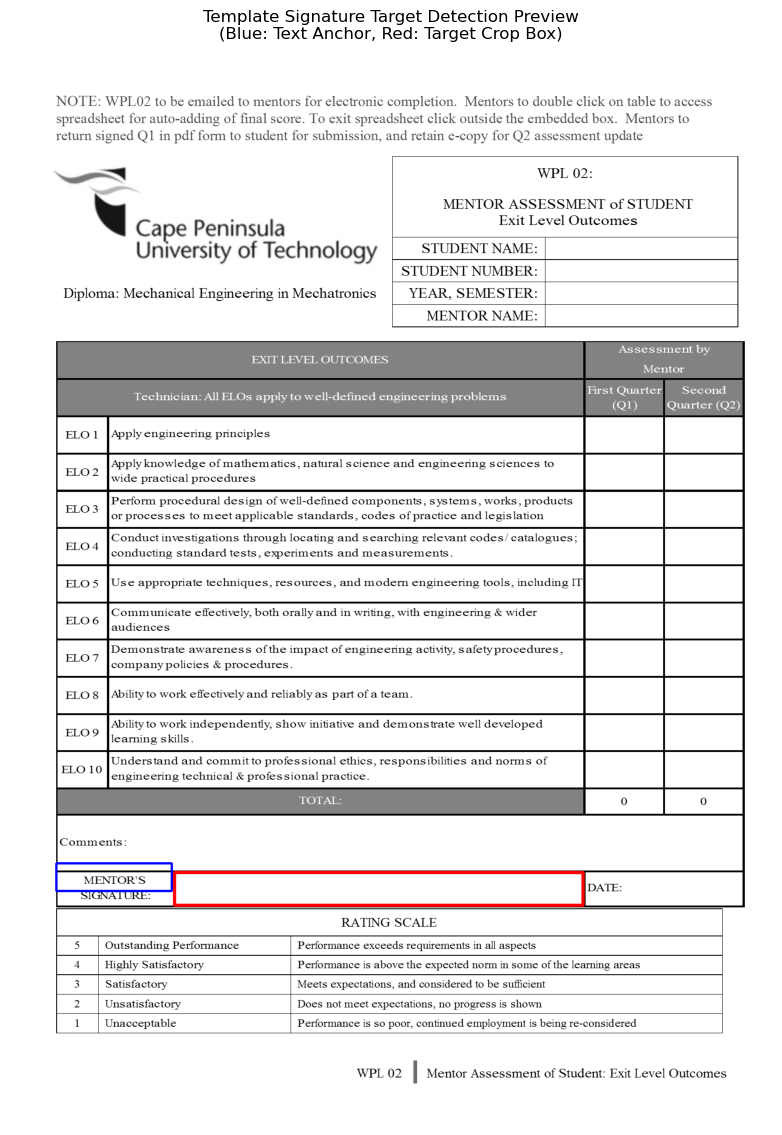

Template signature target box confirmed.

Step 2: Processing and previewing a random scan...
Previewing Image: data/raw_scans/013.png
[extract_image_blocks] INFO - Processing page: preview_013 from data/raw_scans/013.png
[extract_image_blocks] INFO - Image dimensions already match full page. Bypassing homography...
[crop_dynamic_region] INFO - Loading anchor template image: data/templates/extraction/signature_anchor.png
[crop_dynamic_region] INFO - Performing template matching using cv2.TM_CCOEFF_NORMED
[crop_dynamic_region] SUCCESS - Match confidence: 0.68 (Threshold: 0.55) at (764, 1374)
[crop_dynamic_region] SUCCESS - Cropping region (1020:1653, 1394:1465)
[extract_image_blocks] SUCCESS - Cropped signature saved to: data/output/signatures/preview_013.png
[extract_image_blocks] SUCCESS - Alignment and extraction completed for page: preview_013


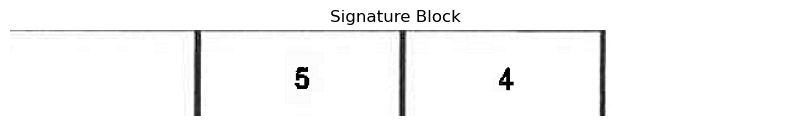

Batch processing aborted by user in scan preview.


In [4]:
# 4. Batch Processing Loop
def run_batch_process():
    try:
        df = pd.read_csv(CSV_PATH)
    except Exception as e:
        logging.error(f"[run_batch_process] ERROR - Error loading CSV: {e}")
        print(f"Error loading CSV: {e}")
        return

    success_count = 0
    
    for index, row in df.iterrows():
        try:
            page_no = str(int(row['Page No.'])).zfill(3)
            student_number = str(row.get('Student Number', ''))
            
            img_path_png = os.path.join(SCANS_DIR, f"{page_no}.png")
            img_path_jpg = os.path.join(SCANS_DIR, f"{page_no}.jpg")
            image_path = img_path_png if os.path.exists(img_path_png) else img_path_jpg
            
            crops = None
            if os.path.exists(image_path):
                crops = extract_image_blocks(image_path, page_no)
            else:
                logging.warning(f"[run_batch_process] WARNING - Image missing for Page {page_no}. Document will be generated without dynamic signature.")
                print(f"[WARN] Image {page_no} missing.")

            # Load Template
            try:
                doc = DocxTemplate(TEMPLATE_PATH)
            except Exception as e:
                logging.error(f"[run_batch_process] ERROR - Error loading template: {TEMPLATE_PATH} ({e})")
                print(f"Error loading word template from {TEMPLATE_PATH}: {e}")
                return
            
            # Prepare context mapping (mapping Comments from table directly to template 'comment')
            context = {
                'student_name': row.get('Student Name', ''),
                'student_number': student_number,
                'year': row.get('Year', ''),
                'mentor_name': row.get('Mentor Name', ''),
                'comment': row.get('Comments', ''),
                'date': ''  # Omitted for now
            }

            # Inject signature if successfully cropped
            if crops and 'signature' in crops:
                context['signature_block'] = InlineImage(doc, crops['signature'], width=Mm(60))
            else:
                context['signature_block'] = "SIGNATURE MISSING"

            doc.render(context)
            
            out_doc_path = os.path.join(OUTPUT_DOCS_DIR, f"Page_{page_no}_Assessment.docx")
            doc.save(out_doc_path)
            logging.info(f"[run_batch_process] SUCCESS - Generated Document: {out_doc_path}")
            success_count += 1
            
        except Exception as e:
            logging.error(f"[run_batch_process] ERROR - Row {index} (Page {row.get('Page No.', 'Unknown')}): {e}")
            print(f"[ERROR] Row {index}: {e}")

    print(f"Batch completed! Successfully generated {success_count} documents.")

# Execution Trigger
if __name__ == "__main__":
    print("Step 1: Visualizing signature target box on the master template...")
    if preview_template_signature_box():
        print("Template signature target box confirmed.\n")
        print("Step 2: Processing and previewing a random scan...")
        if preview_random_row():
            print("Random scan preview confirmed. Starting batch process...")
            run_batch_process()
            logging.info("[main] SUCCESS - Full batch process executed successfully")
        else:
            print("Batch processing aborted by user in scan preview.")
            logging.warning("[main] WARNING - Batch process aborted by user in scan preview")
    else:
        print("Batch processing aborted by user in template preview.")
        logging.warning("[main] WARNING - Batch process aborted by user in template preview")
